In [ ]:
from google.colab import drive
import zipfile, os

# Mount your Google Drive
drive.mount('/content/drive')

# Path to the zip file
zip_path = '/content/drive/MyDrive/SMIDS.zip'
extract_path = '/content/SMIDS'

# Extract only if not already done
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

print("Extracted folders:", os.listdir(extract_path))


Mounted at /content/drive
Extracted folders: ['Normal_Sperm', 'Non-Sperm', 'Abnormal_Sperm']


In [ ]:
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

base_path = '/content/SMIDS'
classes = sorted(os.listdir(base_path))  # Ensure consistent label order
print("Classes found:", classes)

X, y = [], []

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, (224, 224))
            X.append(img)
            y.append(cls)

# Convert to NumPy arrays
X = np.array(X, dtype=np.uint8)
y = LabelEncoder().fit_transform(y)

print("✅ Loaded data:")
print("X shape:", X.shape)
print("y sample:", y[:10])


Classes found: ['Abnormal_Sperm', 'Non-Sperm', 'Normal_Sperm']
✅ Loaded data:
X shape: (3000, 224, 224, 3)
y sample: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from collections import Counter

label_names = sorted(os.listdir(base_path))
label_counts = Counter(y)
decoded_labels = LabelEncoder().fit(label_names).inverse_transform(list(label_counts.keys()))

for name, count in zip(decoded_labels, label_counts.values()):
    print(f"{name}: {count} images")


Abnormal_Sperm: 1005 images
Non-Sperm: 974 images
Normal_Sperm: 1021 images


In [ ]:
print(y[:30])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print(sorted(set(y)))  # Should return [0, 1, 2]


[np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# One-hot encode
y_encoded = to_categorical(y, num_classes=3)

# Stratified split to maintain class distribution
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=np.argmax(y_temp, axis=1), random_state=42)

# Normalize pixel values
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

print("✅ Split successful!")
print(f"Train shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Val shape: {X_val.shape}, Labels: {y_val.shape}")
print(f"Test shape: {X_test.shape}, Labels: {y_test.shape}")


✅ Split successful!
Train shape: (2100, 224, 224, 3), Labels: (2100, 3)
Val shape: (450, 224, 224, 3), Labels: (450, 3)
Test shape: (450, 224, 224, 3), Labels: (450, 3)


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Load pre-trained DenseNet121 base
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Freeze base model layers
base_model.trainable = False

# Custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,091 (27.35 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


66/66 ━━━━━━━━━━━━━━━━━━━━ 476s 7s/step - accuracy: 0.3961 - loss: 1.1855 - val_accuracy: 0.6644 - val_loss: 0.8081
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 493s 7s/step - accuracy: 0.5877 - loss: 0.8826 - val_accuracy: 0.7156 - val_loss: 0.6928
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 504s 7s/step - accuracy: 0.6871 - loss: 0.7483 - val_accuracy: 0.7400 - val_loss: 0.6451
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 504s 7s/step - accuracy: 0.6905 - loss: 0.6989 - val_accuracy: 0.7444 - val_loss: 0.6243
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 504s 7s/step - accuracy: 0.7140 - loss: 0.6399 - val_accuracy: 0.7667 - val_loss: 0.5885
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 500s 7s/step - accuracy: 0.7331 - loss: 0.6390 - val_accuracy: 0.7822 - val_loss: 0.5609
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 502s 7s/step - accuracy: 0.7565 - loss: 0.5889 - val_accuracy: 0.7867 - val_loss: 0.5468
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 503s 7s/step - accuracy: 0.7522 - loss: 0.5945 - val_accuracy: 0.7800 - val_loss: 0.

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the original class names
label_names = sorted(os.listdir('/content/SMIDS'))  # Path to your dataset directory
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}% | Test Loss: {test_loss:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 80s 5s/step - accuracy: 0.8015 - loss: 0.5456
Test Accuracy: 78.67% | Test Loss: 0.5208


In [ ]:
# Predict classes
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_names))  # Pass label_names here

15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step

Classification Report:

                precision    recall  f1-score   support

Abnormal_Sperm       0.72      0.72      0.72       151
     Non-Sperm       0.92      0.81      0.86       146
  Normal_Sperm       0.74      0.83      0.78       153

      accuracy                           0.79       450
     macro avg       0.80      0.79      0.79       450
  weighted avg       0.79      0.79      0.79       450



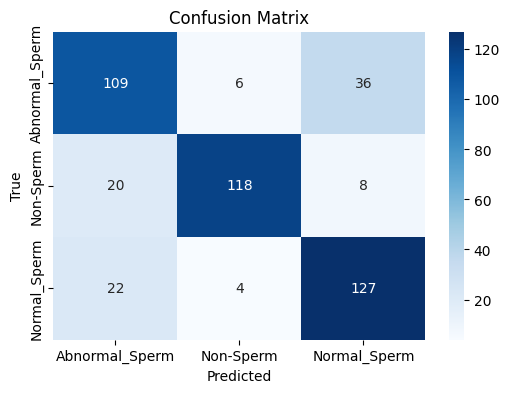

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)  # Pass label_names here
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
model.save('smids_densenet_model2.h5')
print("Model saved as smids_densenet_model2.h5")


Model saved as smids_densenet_model2.h5


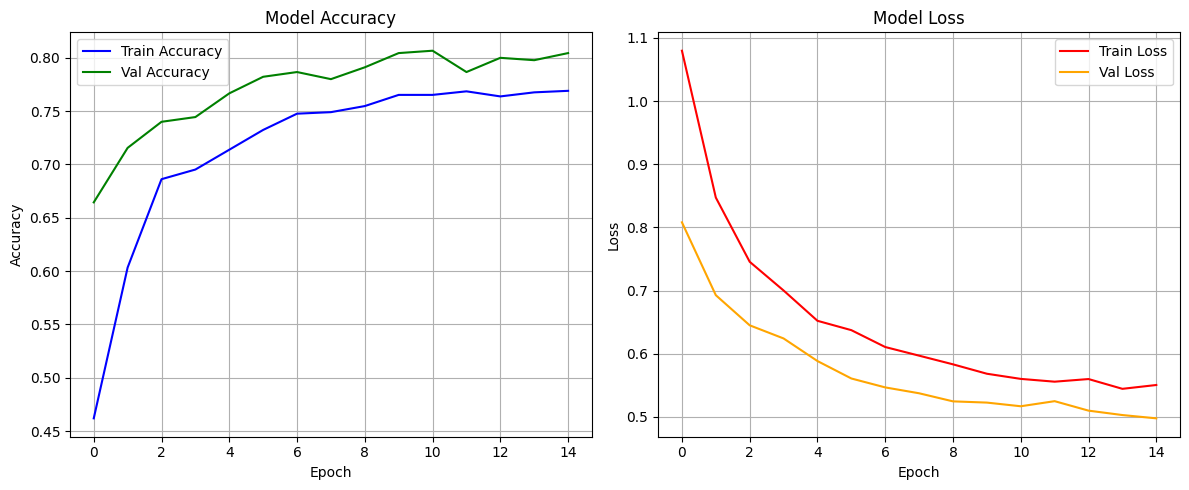

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='green')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 80s 5s/step


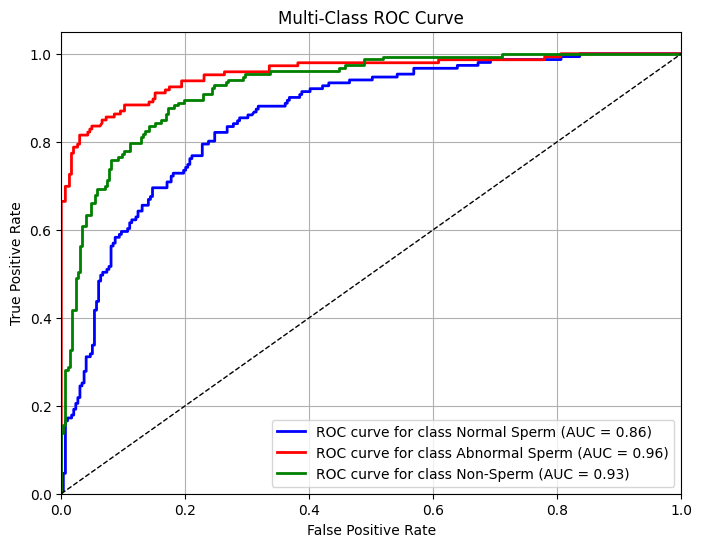

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# Step 1: Predict Probabilities for the Test Set
y_pred_probs = model.predict(X_test)

# Step 2: Binarize the test labels (one-hot encoding)
# Example: If 3 classes, class names = ['Normal_Sperm', 'Abnormal_Sperm', 'Non-Sperm']
n_classes = 3
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Step 3: Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 4: Plot the ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green'])
class_names = ['Normal Sperm', 'Abnormal Sperm', 'Non-Sperm']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Reshape, Dense, Multiply, Add, Activation,
    Conv2D, Concatenate, Lambda
)
import tensorflow.keras.backend as K

def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    shared_dense_one = Dense(channel // ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True)
    shared_dense_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True)

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    max_pool = Lambda(lambda x: K.max(x, axis=[1, 2], keepdims=True))(input_feature)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    cbam_channel = Add()([avg_pool, max_pool])
    cbam_channel = Activation('sigmoid')(cbam_channel)
    channel_refined_feature = Multiply()([input_feature, cbam_channel])

    # ----- Spatial Attention -----
    avg_pool_spatial = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(channel_refined_feature)
    max_pool_spatial = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(channel_refined_feature)
    concat = Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])

    cbam_spatial = Conv2D(filters=1,
                          kernel_size=7,
                          strides=1,
                          padding='same',
                          activation='sigmoid',
                          kernel_initializer='he_normal',
                          use_bias=False)(concat)

    refined_feature = Multiply()([channel_refined_feature, cbam_spatial])
    return refined_feature


In [ ]:
x = cbam_block(base_model.output)  # 👈 Now works fine
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_431']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)
Exception ignored in: <function _xla_gc_callback at 0x78690ba928e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


66/66 ━━━━━━━━━━━━━━━━━━━━ 539s 7s/step - accuracy: 0.3806 - loss: 1.0871 - val_accuracy: 0.6600 - val_loss: 0.9321
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 487s 7s/step - accuracy: 0.6522 - loss: 0.8777 - val_accuracy: 0.7000 - val_loss: 0.7160
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 506s 7s/step - accuracy: 0.6953 - loss: 0.6950 - val_accuracy: 0.7356 - val_loss: 0.6273
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 455s 7s/step - accuracy: 0.7528 - loss: 0.6017 - val_accuracy: 0.7578 - val_loss: 0.5834
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 502s 7s/step - accuracy: 0.7678 - loss: 0.5474 - val_accuracy: 0.7578 - val_loss: 0.5403
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 501s 7s/step - accuracy: 0.7884 - loss: 0.5254 - val_accuracy: 0.7667 - val_loss: 0.5274
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 504s 7s/step - accuracy: 0.8141 - loss: 0.4611 - val_accuracy: 0.7756 - val_loss: 0.4968
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 504s 7s/step - accuracy: 0.8210 - loss: 0.4557 - val_accuracy: 0.7956 - val_loss: 0.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}% | Test Loss: {test_loss:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.8052 - loss: 0.5259
Test Accuracy: 80.44% | Test Loss: 0.5105


In [ ]:
# Save the full model to your Drive
model.save('/content/drive/MyDrive/SMIDS_CBAM_DenseNet_model.h5')
print("✅ Model saved successfully!")


✅ Model saved successfully!


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_431']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


15/15 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step

Classification Report:

                precision    recall  f1-score   support

Abnormal_Sperm       0.73      0.73      0.73       151
     Non-Sperm       0.95      0.81      0.87       146
  Normal_Sperm       0.76      0.88      0.81       153

      accuracy                           0.80       450
     macro avg       0.82      0.80      0.81       450
  weighted avg       0.81      0.80      0.81       450



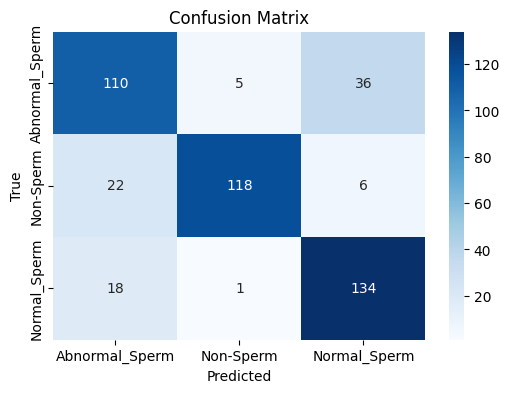

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict classes
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Class names from folder structure
label_names = sorted(os.listdir('/content/SMIDS'))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
